# Required libraries

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import OrdinalEncoder ,LabelEncoder 
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


# Dataset setup

## Dataset downloading

In [2]:
#loading data from files
data = pd.read_csv("/kaggle/input/census-income-data-set/adult.csv")
#including only categorical features
data_categorical = data.select_dtypes(include=['object'])
#filling all missing values with 'Missing'
data_categorical = data_categorical.fillna('Missing')
data_categorical = data_categorical.astype(str)


## Dataset encoding 

In [3]:
# education encoding 
education_order = [
   "Missing", "Preschool","1st-4th","5th-6th","7th-8th","9th","10th","11th","12th",
    "HS-grad",
    "Some-college",
    "Assoc-acdm", "Assoc-voc",
    "Prof-school",
    "Bachelors","Masters","Doctorate"
]
education_encoded = OrdinalEncoder(categories=[education_order])
data_categorical['education'] = education_encoded.fit_transform(
    data_categorical['education'].values.reshape(-1, 1)
)
#encoding other features
categorical_cols = ['workclass', 'marital.status', 'occupation', 
                    'relationship', 'race', 'sex', 'native.country']

for col in categorical_cols:
    data_categorical[col] = LabelEncoder().fit_transform(data_categorical[col])
data_categorical['income'] = LabelEncoder().fit_transform(data_categorical['income'])


## Dataset splitting

In [4]:
data_shuffled = data_categorical.sample(frac=1, random_state=42).reset_index(drop=True)
n = len(data_shuffled)
train_end = int(0.7 * n)
val_end = int(0.85 * n)
#70% trainig data
train_data = data_shuffled.iloc[:train_end]
#15% validation data
val_data   = data_shuffled.iloc[train_end:val_end]
#15% test data
test_data  = data_shuffled.iloc[val_end:]

## Data separation

In [5]:
#Assigning x arrays for features and y arrays for targets 
x_train = train_data.drop("income", axis=1)
x_train_np = x_train.to_numpy ()

y_train = train_data["income"]
y_train_np = y_train.to_numpy ()


x_val = val_data.drop("income", axis=1)
x_val_np = x_val.to_numpy ()

y_val = val_data["income"]
y_val_np = y_val.to_numpy ()

x_test = test_data.drop("income", axis=1)
x_test_np = x_test.to_numpy ()

y_test = test_data["income"]
y_test_np = x_test.to_numpy ()


# Naive bayes implementation

## calculating priors

In [6]:
def calc_prior (alpha , target_dataset):
    total = len (target_dataset)
    counts = {0: 0, 1: 0}
    
    for sample in target_dataset:
        if sample == 0:
            counts [0]+=1 
        else: 
            counts [1] += 1
    priors = {}
    priors[0] = (counts[0]+alpha)/(total+alpha*2)
    priors[1] = (counts[1]+alpha)/(total+alpha*2)
    return counts , priors 

## calculating feature likelihood 

In [7]:
def calc_likelihoods (alpha , feature_dataset, target_dataset):
    counts,_ = calc_prior (alpha , target_dataset)
    labels = counts.keys()
    likelihoods = {}
    for label in labels :
        likelihoods [label] = {}
        label_samples = feature_dataset[target_dataset == label]
        for feature in range(feature_dataset.shape[1]) :
            feature_values = np.unique(feature_dataset[:, feature])
            likelihoods[label][feature] = {}
            for val in feature_values:
                count = np.sum(label_samples[:, feature] == val)
                likelihoods[label][feature][val] = (count+alpha) / (counts[label] + len(feature_values)*alpha)

    return likelihoods              
           
    
    

## Calculating the prediction 

In [8]:
def predict (likelihoods , priors, sample):
    labels = priors.keys()
    posteriors = {}
    for label in labels: 
        posteriors [label] = np.log(priors[label])
        for feature,val in enumerate(sample) :
            posteriors [label] += np.log(likelihoods [label][feature].get(val, 1e-5))
    
    predicted_class = max(posteriors, key=posteriors.get)
    return posteriors , predicted_class 


## Testing the model 

In [9]:
_,priors = calc_prior (1 , y_train_np)
likelihoods = calc_likelihoods (1 , x_train_np, y_train_np)
predictions = []
for  i,sample in enumerate(x_test_np) :
     _, pred_class = predict(likelihoods, priors, sample)
     predictions.append(pred_class)
accuracy = np.sum(np.array(predictions) == y_test) / len(y_test)
print ("Accuracy : " , accuracy)
print ("Posterior : ", priors)


Accuracy :  0.7942681678607983
Posterior :  {0: 0.757874879354216, 1: 0.24212512064578398}


# Analysis

## 1. Smoothing Parameter

In [10]:
# for multiple alpha values 
values = [0.1,0.5,1,2,5]
accuracy = {}
for alpha in values :
    _,priors = calc_prior (alpha , y_train_np)
    likelihoods = calc_likelihoods (alpha , x_train_np, y_train_np)
    predictions = []
    for  i,sample in enumerate(x_val_np) :
         _, pred_class = predict(likelihoods, priors, sample)
         predictions.append(pred_class)
    accuracy[alpha]  = np.sum(np.array(predictions) == y_val) / len(y_val)

print ("Accuracy : ",accuracy)

Accuracy :  {0.1: 0.8024160524160524, 0.5: 0.8022113022113022, 1: 0.8024160524160524, 2: 0.8018018018018018, 5: 0.800982800982801}


#### Smoothing parameter is a way to prevent zero probabilities that is a result of unseen feauture value. As alpha increases it makes the model less sensitive to unseen or rare feautures values

## 2. Analysis of feature selection

### 1. Selecting only occupation and education 

In [11]:
unselected_features = ['workclass', 'marital.status', 
                    'relationship', 'race', 'sex', 'native.country','income']
# selected train data 
x_train_selected = train_data.drop( unselected_features , axis=1)
x_train_selected_np = x_train_selected.to_numpy ()

y_train_selected = train_data["income"]
y_train_selected_np = y_train_selected.to_numpy ()

# selected val data 
x_val_selected = val_data.drop( unselected_features , axis=1)
x_val_selected_np = x_val_selected.to_numpy ()

y_val_selected = val_data["income"]
y_val_selected_np = y_val_selected.to_numpy ()

#testing model

_,priors = calc_prior (1 , y_train_selected_np)
likelihoods = calc_likelihoods (1 , x_train_selected_np, y_train_selected_np)
predictions = []
for  i,sample in enumerate(x_val_selected_np) :
     _, pred_class = predict(likelihoods, priors, sample)
     predictions.append(pred_class)
accuracy = np.sum(np.array(predictions) == y_val) / len(y_val)
print ("Accuracy :",accuracy)
print ("Priors",priors)


Accuracy : 0.7753890253890254
Priors {0: 0.757874879354216, 1: 0.24212512064578398}


### 2. Selecting only occupation, education, workcalss , native country 

In [12]:
unselected_features = [ 'marital.status', 
                    'relationship', 'race', 'sex','income']
# selected train data 
x_train_selected = train_data.drop( unselected_features , axis=1)
x_train_selected_np = x_train_selected.to_numpy ()

y_train_selected = train_data["income"]
y_train_selected_np = y_train_selected.to_numpy ()

# selected val data 
x_val_selected = val_data.drop( unselected_features , axis=1)
x_val_selected_np = x_val_selected.to_numpy ()

y_val_selected = val_data["income"]
y_val_selected_np = y_val_selected.to_numpy ()

#testing model

_,priors = calc_prior (1 , y_train_selected_np)
likelihoods = calc_likelihoods (1 , x_train_selected_np, y_train_selected_np)
predictions = []
for  i,sample in enumerate(x_val_selected_np) :
     _, pred_class = predict(likelihoods, priors, sample)
     predictions.append(pred_class)
accuracy = np.sum(np.array(predictions) == y_val) / len(y_val)
print ("Accuracy :",accuracy)
print ("Priors",priors)


Accuracy : 0.7755937755937756
Priors {0: 0.757874879354216, 1: 0.24212512064578398}


### 3. Selecting only occupation ,education,race ,sex , native country 

In [13]:
unselected_features = ['workclass', 'marital.status', 
                    'relationship','income']
# selected train data 
x_train_selected = train_data.drop( unselected_features , axis=1)
x_train_selected_np = x_train_selected.to_numpy ()

y_train_selected = train_data["income"]
y_train_selected_np = y_train_selected.to_numpy ()

# selected val data 
x_val_selected = val_data.drop( unselected_features , axis=1)
x_val_selected_np = x_val_selected.to_numpy ()

y_val_selected = val_data["income"]
y_val_selected_np = y_val_selected.to_numpy ()

#testing model

_,priors = calc_prior (1 , y_train_selected_np)
likelihoods = calc_likelihoods (1 , x_train_selected_np, y_train_selected_np)
predictions = []
for  i,sample in enumerate(x_val_selected_np) :
     _, pred_class = predict(likelihoods, priors, sample)
     predictions.append(pred_class)
accuracy = np.sum(np.array(predictions) == y_val) / len(y_val)
print ("Accuracy :",accuracy)
print ("Priors",priors)

Accuracy : 0.7889025389025389
Priors {0: 0.757874879354216, 1: 0.24212512064578398}


### 4. Selecting only  race ,sex , native country 

In [14]:
unselected_features = ['workclass', 'marital.status', 
                    'relationship','occupation',  'education','income']
# selected train data 
x_train_selected = train_data.drop( unselected_features , axis=1)
x_train_selected_np = x_train_selected.to_numpy ()

y_train_selected = train_data["income"]
y_train_selected_np = y_train_selected.to_numpy ()

# selected val data 
x_val_selected = val_data.drop( unselected_features , axis=1)
x_val_selected_np = x_val_selected.to_numpy ()

y_val_selected = val_data["income"]
y_val_selected_np = y_val_selected.to_numpy ()

#testing model

_,priors = calc_prior (1 , y_train_selected_np)
likelihoods = calc_likelihoods (1 , x_train_selected_np, y_train_selected_np)
predictions = []
for  i,sample in enumerate(x_val_selected_np) :
     _, pred_class = predict(likelihoods, priors, sample)
     predictions.append(pred_class)
accuracy = np.sum(np.array(predictions) == y_val) / len(y_val)
print ("Accuracy :",accuracy)
print ("Priors",priors)

Accuracy : 0.7577805077805078
Priors {0: 0.757874879354216, 1: 0.24212512064578398}


#### Features selection shows that some features like education and occupation (specialy occupation ) have a great impact on the model accuracy and predictions 
##### education, occupation led to 77.54% .
##### education, occupation, workclass, native.country led to 77.56% .
##### education, occupation, race, sex, native.country led to 78.89% . 
##### race, sex, native.country led to 75.77% .
#### This indicates that education and occupation are the most critical features.

## 3. Probability Analysis

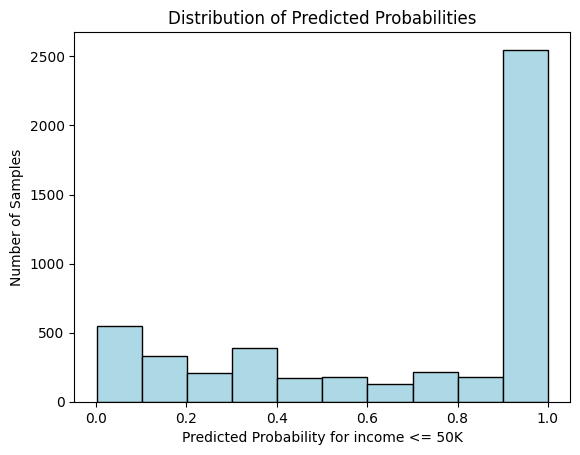

In [15]:
_,priors = calc_prior (1 , y_train_np)
likelihoods = calc_likelihoods (1 , x_train_np, y_train_np)
posteriors = []

for sample in x_val_np:
    log_posterior, _  =  predict(likelihoods, priors, sample)
    exp_posterior = {c: np.exp(v) for c, v in log_posterior.items()}
    total = sum(exp_posterior.values())                           
    probs = {c: exp_posterior[c] / total for c in exp_posterior}
    posteriors.append(probs)
    

class1 = np.array([p[1] for p in posteriors])
class0 = np.array([p[0] for p in posteriors])

plt.hist(class0, edgecolor='black',color = 'lightblue')
plt.xlabel('Predicted Probability for income <= 50K')
plt.ylabel('Number of Samples')
plt.title('Distribution of Predicted Probabilities')
plt.show()


#### This distribution of the posterior probabilities for Class 0 (income < = 50K) in the validation dataset shows that the model was confident about its predictions for most samples.
#### For more than 2,500 samples, the model predicted Class 0 (income < = 50K) with high confidence (probabilities near 1.0), while for about 550 samples, it predicted Class 1 (income > 50K) with high confidence (probabilities near 0.0). Most samples receive confident predictions near 0 or 1, with few uncertain cases in the middle. This indicates the model can clearly separate the two income classes.

## 4. Independence Assumption

### 1. Its violations 

#### The violations happen if some features are related to each other and dependant but naive bayes ignores this and multiply their probabilites from the assumption that they are independant .

### 2. Its impact 

#### If we have highly correlated features , as a result of the multiplications that the naive bayes does , it would decrease their probability . For example we have 2 features highly colerated and their conditional probabilty is 0.9 , what naive bayes does that it will multiply those probability so the result is 0.81 , while the true joint probability is 0.9 , and it could be worse if there were multiple classes dependant on each other , this will lead to 0.9^n , which leads to higher underestimation . 

## 5. sklearn's MultinomialNB

sklearn's MultinomialNB Accuracy: 0.785012285012285
Model Accuracy: 0.8024160524160524
Priors: {0: 0.757874879354216, 1: 0.24212512064578398}


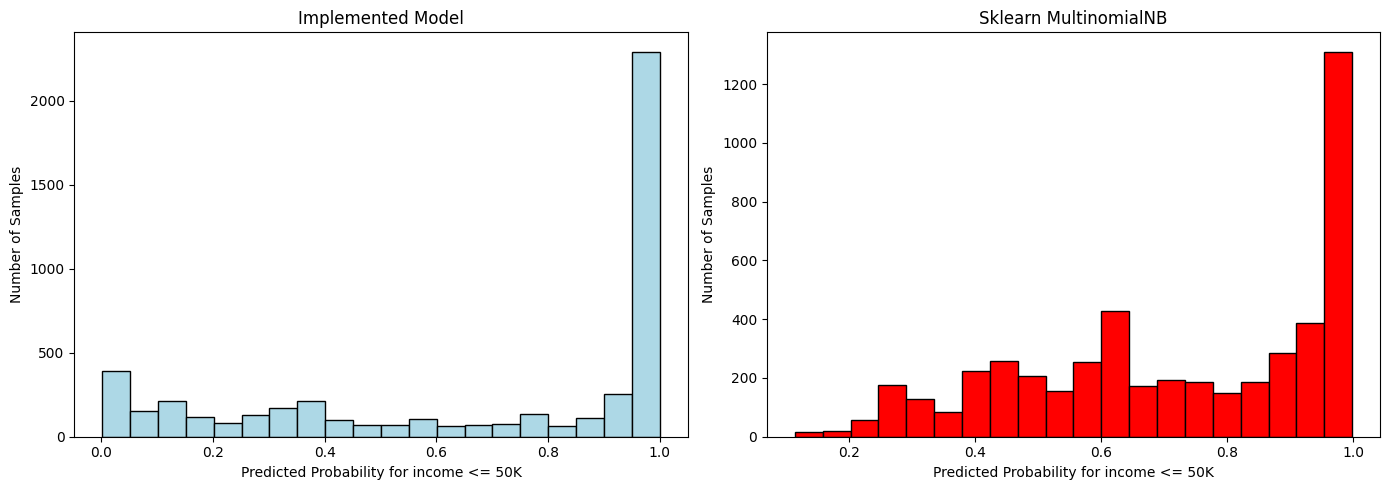

In [16]:
# sklearn model
model = MultinomialNB(alpha=1.0)
model.fit(x_train_np, y_train_np)
NB_prediction = model.predict(x_val_np)
NB_posterior = model.predict_proba(x_val_np)
sklearn_class0 = NB_posterior[:, 0]  
print("sklearn's MultinomialNB Accuracy:", accuracy_score(y_val, NB_prediction))

# implemented model
_,priors = calc_prior (1 , y_train_np)
likelihoods = calc_likelihoods (1 , x_train_np, y_train_np)
predictions = []
posteriors = []
for i, sample in enumerate(x_val_np):
     log_posterior, pred_class = predict(likelihoods, priors, sample)
     exp_posterior = {c: np.exp(v) for c, v in log_posterior.items()}
     total = sum(exp_posterior.values())                           
     probs = {c: exp_posterior[c] / total for c in exp_posterior}
     posteriors.append(probs)
     predictions.append(pred_class)
    
accuracy = np.sum(np.array(predictions) == y_val) / len(y_val)
print("Model Accuracy:", accuracy)
print("Priors:", priors)

class0 = np.array([p[0] for p in posteriors])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(class0, bins = 20 ,edgecolor='black', color='lightblue')
axes[0].set_xlabel('Predicted Probability for income <= 50K')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Implemented Model')

axes[1].hist(sklearn_class0, bins = 20 , edgecolor='black', color='red')
axes[1].set_xlabel('Predicted Probability for income <= 50K')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Sklearn MultinomialNB')

plt.tight_layout()
plt.show()

#### The difference in accuracy between the sklearn MultinomialNB model and the manually implemented model is about 1.7%.
#### if we changed the dateset used to get the samples it might achieve different results .
#### The histogram show that the implemnted model is more confident about its predictions as it specifically designed for categorical features , while MultinomialNB model is designed for count data . Despite that it achieved a similar accuracy at the end .